In [8]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#Load Dataset
df = pd.read_csv("/content/cleaned_us_education_data.csv")
df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE,FUNDING_PER_STUDENT
0,2003_ALABAMA,ALABAMA,2003,727900.0,5196054.0,567704.0,2966981.0,1661369.0,5298932.0,2817111.0,...,59663.0,42005.0,466920.0,205907.0,731220.0,223.0,262.0,207.0,253.0,7.279753
1,2003_ALASKA,ALASKA,2003,133303.0,1425948.0,259423.0,813371.0,353154.0,1610289.0,763525.0,...,11140.0,8651.0,82337.0,40238.0,133933.0,233.0,279.0,212.0,256.0,12.079916
2,2003_ARIZONA,ARIZONA,2003,875111.0,6529894.0,740579.0,2912629.0,2876686.0,6210287.0,2810907.0,...,76376.0,68815.0,613442.0,307272.0,1012068.0,229.0,271.0,209.0,255.0,7.096571
3,2003_ARKANSAS,ARKANSAS,2003,450158.0,3241275.0,379947.0,2394336.0,466992.0,3242799.0,1768713.0,...,37004.0,28840.0,281834.0,132712.0,454523.0,229.0,266.0,214.0,258.0,7.203691
4,2003_CALIFORNIA,CALIFORNIA,2003,6226552.0,59815855.0,5795655.0,33617766.0,20402434.0,59749885.0,29561563.0,...,500143.0,395194.0,3929869.0,1854518.0,6413867.0,227.0,267.0,206.0,251.0,9.595983


In [10]:
#Basic Exploration
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PRIMARY_KEY                   357 non-null    object 
 1   STATE                         357 non-null    object 
 2   YEAR                          357 non-null    int64  
 3   ENROLL                        357 non-null    float64
 4   TOTAL_REVENUE                 357 non-null    float64
 5   FEDERAL_REVENUE               357 non-null    float64
 6   STATE_REVENUE                 357 non-null    float64
 7   LOCAL_REVENUE                 357 non-null    float64
 8   TOTAL_EXPENDITURE             357 non-null    float64
 9   INSTRUCTION_EXPENDITURE       357 non-null    float64
 10  SUPPORT_SERVICES_EXPENDITURE  357 non-null    float64
 11  OTHER_EXPENDITURE             357 non-null    float64
 12  CAPITAL_OUTLAY_EXPENDITURE    357 non-null    float64
 13  GRADE

,0
PRIMARY_KEY,0
STATE,0
YEAR,0
ENROLL,0
TOTAL_REVENUE,0
FEDERAL_REVENUE,0
STATE_REVENUE,0
LOCAL_REVENUE,0
TOTAL_EXPENDITURE,0
INSTRUCTION_EXPENDITURE,0


In [11]:
#Drop rows with missing values
df = df.dropna(subset=[
    'TOTAL_EXPENDITURE',
    'ENROLL',
    'AVG_MATH_8_SCORE',
    'AVG_READING_8_SCORE'
])

In [12]:
#Create Funding Per Student
df['FUNDING_PER_STUDENT'] = df['TOTAL_EXPENDITURE'] / df['ENROLL']
df[['STATE','FUNDING_PER_STUDENT']].head()

,STATE,FUNDING_PER_STUDENT
0,ALABAMA,7.279753
1,ALASKA,12.079916
2,ARIZONA,7.096571
3,ARKANSAS,7.203691
4,CALIFORNIA,9.595983


In [7]:
# df.to_csv("/content/cleaned_us_education_data.csv", index=False)

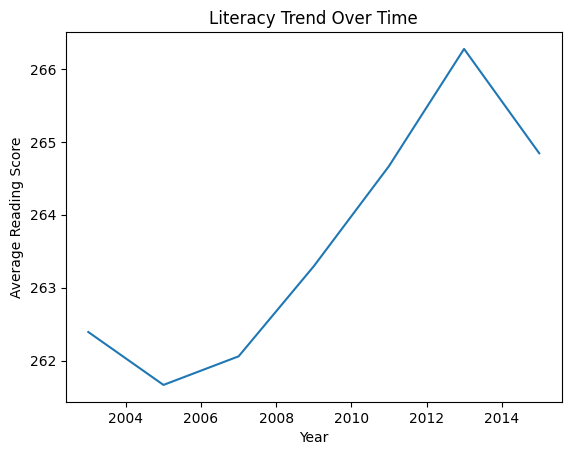

In [13]:
#========================
# Literacy Rates Analysis
#========================

# 1. Literacy Trend Over Time

plt.figure()
df.groupby('YEAR')['AVG_READING_8_SCORE'].mean().plot()
plt.xlabel("Year")
plt.ylabel("Average Reading Score")
plt.title("Literacy Trend Over Time")
plt.show()

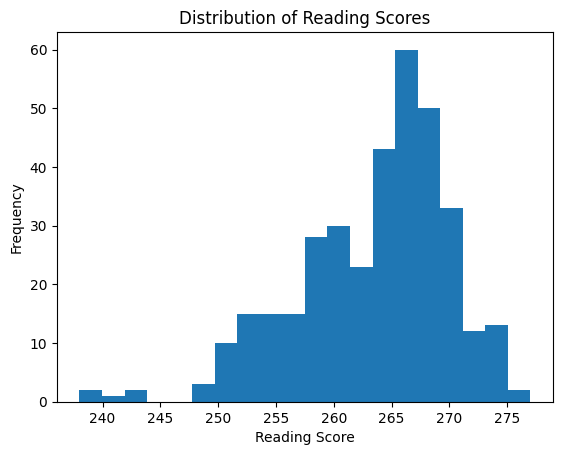

In [14]:
# 2.Literacy Scores Distribution

plt.figure()
plt.hist(df['AVG_READING_8_SCORE'], bins=20)
plt.title("Distribution of Reading Scores")
plt.xlabel("Reading Score")
plt.ylabel("Frequency")
plt.show()

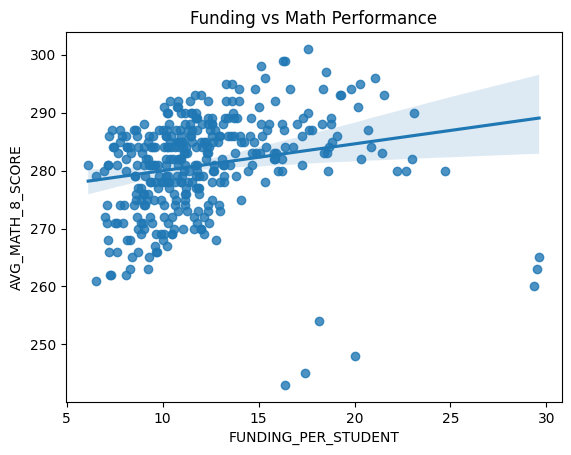

In [15]:
#===================================
# Funding vs Performance Correlation
#====================================

# 1.Funding per Student

sns.regplot(x='FUNDING_PER_STUDENT',
            y='AVG_MATH_8_SCORE',
            data=df)

plt.title("Funding vs Math Performance")
plt.show()

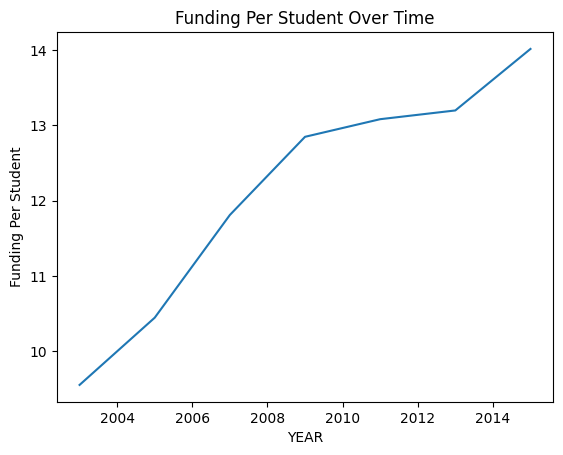

In [16]:
# 2. Funding Trend Over Time

plt.figure()
df.groupby('YEAR')['FUNDING_PER_STUDENT'].mean().plot()
plt.title("Funding Per Student Over Time")
plt.ylabel("Funding Per Student")
plt.show()

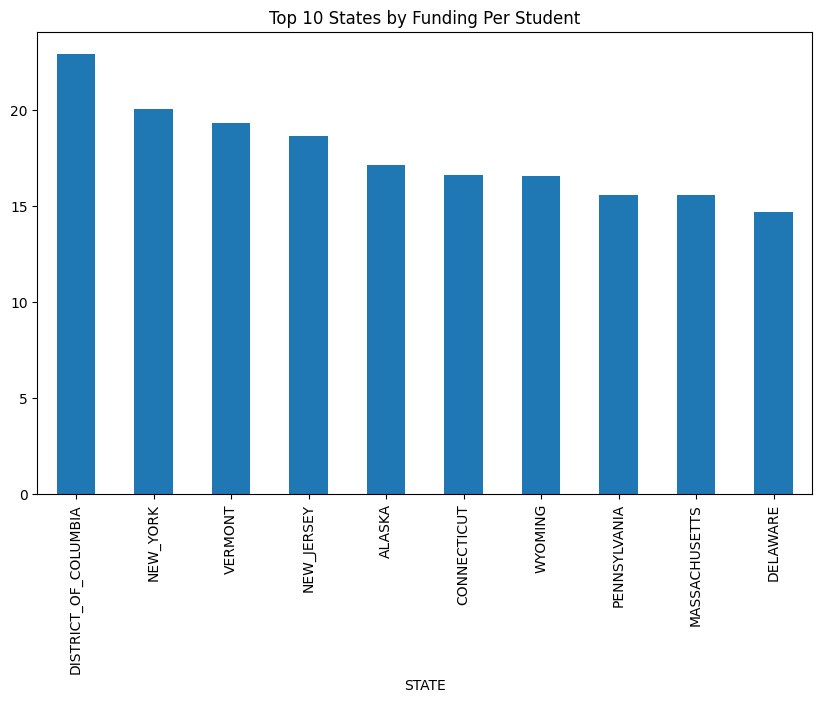

In [17]:
# 3. State-wise Funding Comparison

state_funding = df.groupby('STATE')['FUNDING_PER_STUDENT'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
state_funding.head(10).plot(kind='bar')
plt.title("Top 10 States by Funding Per Student")
plt.show()